In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.append("/home/z5297792/UNSW-MRes/MRes/modules") 
from utils import unit_det



In [2]:
width=500
x = np.linspace(-width // 2, width // 2, 501)
y = np.linspace(-width // 2, width // 2, 501)
X, Y = np.meshgrid(x, y, indexing='ij')

xc, yc = 0.0, 0.0
Q11, Q12, Q22 = 1., 0., 1.
psi0 = 250.0 
Rc = 85.0 
A = - psi0 / Rc**2

# rescale Q to have unit determinant
Q, _ = unit_det(Q=np.array([[Q11, Q12], [Q12, Q22]]))
q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]

w = 2*A*(q11+q22)*1e-3
Omega = 2*A#*1e-3

dx, dy = X - xc, Y - yc
rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
Qr2 = (q11*dx + q12*dy)**2 + (q12*dx + q22*dy)**2 # ||Qr||
psi = psi0 * np.exp( - rho2 / Rc**2 )
u =   psi0 * np.exp( - rho2 / Rc**2 ) * ( 2*q12*dx + 2*q22*dy ) / Rc**2
v = - psi0 * np.exp( - rho2 / Rc**2 ) * ( 2*q11*dx + 2*q12*dy ) / Rc**2
cs = np.hypot(u, v)

u_core = - Omega * dy
v_core = Omega * dx
cs_core = np.hypot(u_core, v_core)


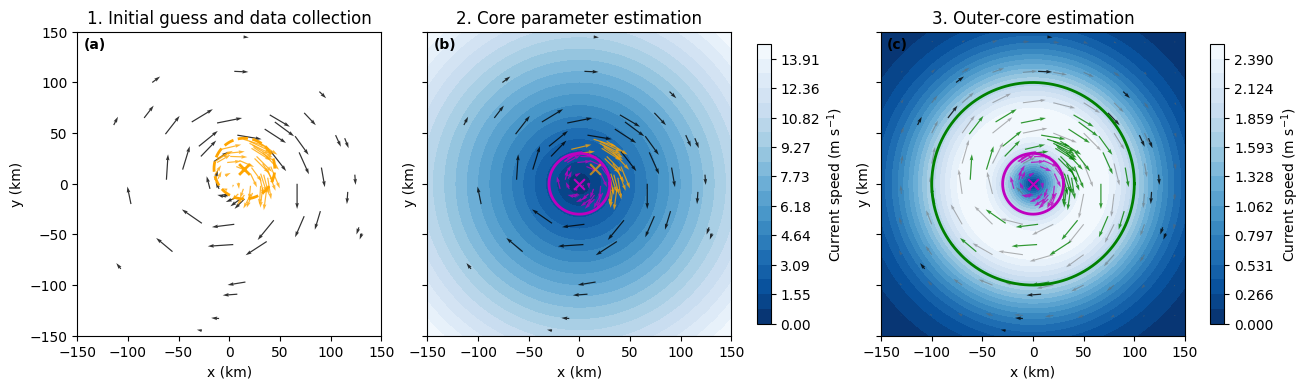

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(13, 4.2), sharex=True, sharey=True, constrained_layout=True)

n = 100
n_core = 40
n_outer = n - n_core

s = 60
spac = 30
scale = 30
width = 0.004

core_r = 30
outer_r = 100
outer_sample_r = 175

x0, y0 = 15, 15
lim = 150
init_color = 'orange'

theta = np.linspace(0, 2*np.pi, 400)

# ---------------- Sample points: dense in core, sparse outside ----------------
theta_core = 2*np.pi*np.random.rand(n_core)
r_core = core_r * np.sqrt(np.random.rand(n_core))

theta_outer = 2*np.pi*np.random.rand(n_outer)
r_outer = core_r + (outer_sample_r - core_r) * np.random.rand(n_outer)**2

xs = np.r_[x0 + r_core*np.cos(theta_core), x0 + r_outer*np.cos(theta_outer)]
ys = np.r_[y0 + r_core*np.sin(theta_core), y0 + r_outer*np.sin(theta_outer)]

idx = np.array([
    np.unravel_index(np.argmin((X - xx)**2 + (Y - yy)**2), X.shape)
    for xx, yy in zip(xs, ys)
])
ii, jj = idx[:, 0], idx[:, 1]

xi, yi = X[ii, jj], Y[ii, jj]
ui, vi = u[ii, jj], v[ii, jj]

# ---------------- Restrict contourf to plotted region ----------------
mask_dom = (X < -lim) | (X > lim) | (Y < -lim) | (Y > lim)

cs_core_plot = np.ma.masked_where(mask_dom, cs_core)
cs_plot = np.ma.masked_where(mask_dom, cs)

levels2 = np.linspace(cs_core_plot.min(), cs_core_plot.max(), 20)
levels3 = np.linspace(cs_plot.min(), cs_plot.max(), 20)

for ax in axs:
    ax.set_aspect('equal')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')

# ---------------- Masks ----------------
init_mask = np.hypot(xi - x0, yi - y0) < core_r
core_mask = np.hypot(xi - xc, yi - yc) < core_r
bad_mask = init_mask & ~core_mask
other_mask_2 = ~(core_mask | bad_mask)

out_mask = np.hypot(xi - xc, yi - yc) < outer_r
out_mask = out_mask & ~core_mask
other_mask_3 = ~(core_mask | out_mask)

# ---------------- Panel 1 ----------------
axs[0].set_title('1. Initial guess and data collection')

axs[0].quiver(xi[~init_mask], yi[~init_mask], ui[~init_mask], vi[~init_mask],
              scale=scale, color='k', alpha=0.8, width=width)
axs[0].quiver(xi[init_mask], yi[init_mask], ui[init_mask], vi[init_mask],
              scale=scale, color=init_color, alpha=0.8, width=width)

axs[0].scatter(x0, y0, marker='x', color=init_color, s=s, linewidths=2)
axs[0].plot(x0 + core_r*np.cos(theta), y0 + core_r*np.sin(theta),
            color=init_color, linestyle='--', linewidth=2)

# ---------------- Panel 2 ----------------
axs[1].set_title('2. Core parameter estimation')

cf2 = axs[1].contourf(X, Y, cs_core_plot, levels=levels2, cmap='Blues_r')

axs[1].quiver(xi[other_mask_2], yi[other_mask_2], ui[other_mask_2], vi[other_mask_2],
              scale=scale, color='k', alpha=0.8, width=width)
axs[1].quiver(xi[bad_mask], yi[bad_mask], ui[bad_mask], vi[bad_mask],
              scale=scale, color=init_color, alpha=0.8, width=width)
axs[1].quiver(xi[core_mask], yi[core_mask], ui[core_mask], vi[core_mask],
              scale=scale, color='m', alpha=0.8, width=width)

axs[1].scatter(x0, y0, marker='x', color=init_color, s=s, alpha=0.7)
axs[1].scatter(xc, yc, marker='x', color='m', s=s)
axs[1].plot(xc + core_r*np.cos(theta), yc + core_r*np.sin(theta),
            color='m', linewidth=2)

# ---------------- Panel 3 ----------------
axs[2].set_title('3. Outer-core estimation')

cf3 = axs[2].contourf(X, Y, cs_plot, levels=levels3, cmap='Blues_r')

axs[2].quiver(X[::spac, ::spac], Y[::spac, ::spac],
              u[::spac, ::spac], v[::spac, ::spac],
              color='0.4', alpha=0.5, scale=scale)

axs[2].quiver(xi[other_mask_3], yi[other_mask_3], ui[other_mask_3], vi[other_mask_3],
              scale=scale, color='k', alpha=0.8, width=width)
axs[2].quiver(xi[core_mask], yi[core_mask], ui[core_mask], vi[core_mask],
              scale=scale, color='m', alpha=0.8, width=width)
axs[2].quiver(xi[out_mask], yi[out_mask], ui[out_mask], vi[out_mask],
              scale=scale, color='g', alpha=0.8, width=width)

axs[2].scatter(xc, yc, marker='x', color='m', s=s)
axs[2].plot(xc + core_r*np.cos(theta), yc + core_r*np.sin(theta),
            color='m', linewidth=2)
axs[2].plot(xc + outer_r*np.cos(theta), yc + outer_r*np.sin(theta),
            color='g', linewidth=2)

cbar2 = fig.colorbar(cf2, ax=axs[1], fraction=0.046, pad=0.04)
cbar2.set_label(r'Current speed (m s$^{-1}$)')

cbar3 = fig.colorbar(cf3, ax=axs[2], fraction=0.046, pad=0.04)
cbar3.set_label(r'Current speed (m s$^{-1}$)')

for ax, lab in zip(axs, ['(a)', '(b)', '(c)']):
    ax.text(0.02, 0.98, lab, transform=ax.transAxes,
            va='top', fontweight='bold')
    

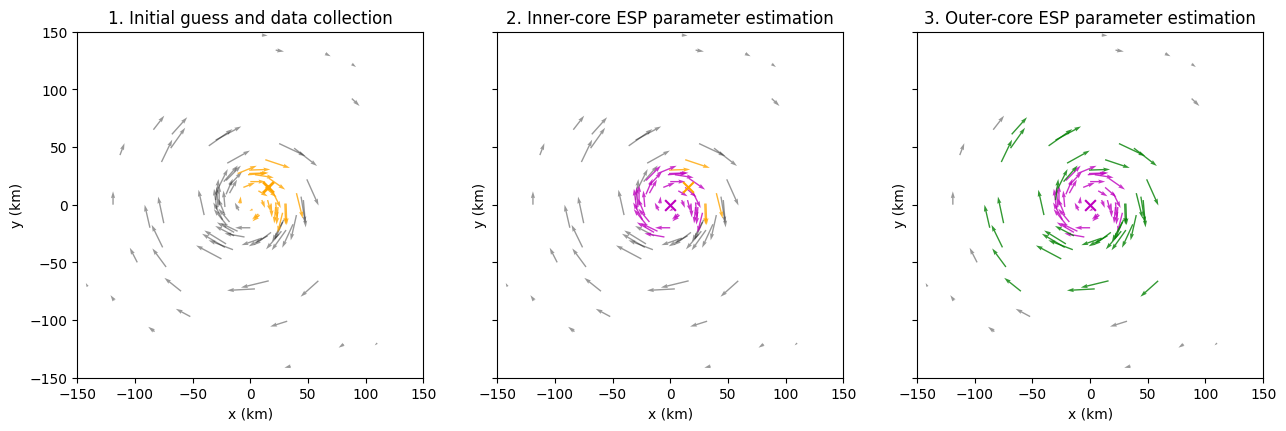

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(13, 4.2), sharex=True, sharey=True, constrained_layout=True)

n = 100
n_core = 40
n_outer = n - n_core

s = 60
spac = 30
scale = 30
width = 0.004

core_r = 30
outer_r = 100
outer_sample_r = 175

x0, y0 = 15, 15
lim = 150
init_color = 'orange'

theta = np.linspace(0, 2*np.pi, 400)

# ---------------- Sample points: dense in core, sparse outside ----------------
theta_core = 2*np.pi*np.random.rand(n_core)
r_core = core_r * np.sqrt(np.random.rand(n_core))

theta_outer = 2*np.pi*np.random.rand(n_outer)
r_outer = core_r + (outer_sample_r - core_r) * np.random.rand(n_outer)**2

xs = np.r_[r_core*np.cos(theta_core), r_outer*np.cos(theta_outer)]
ys = np.r_[r_core*np.sin(theta_core), r_outer*np.sin(theta_outer)]

idx = np.array([
    np.unravel_index(np.argmin((X - xx)**2 + (Y - yy)**2), X.shape)
    for xx, yy in zip(xs, ys)
])
ii, jj = idx[:, 0], idx[:, 1]

xi, yi = X[ii, jj], Y[ii, jj]
ui, vi = u[ii, jj], v[ii, jj]

# ---------------- Restrict contourf to plotted region ----------------
mask_dom = (X < -lim) | (X > lim) | (Y < -lim) | (Y > lim)

cs_core_plot = np.ma.masked_where(mask_dom, cs_core)
cs_plot = np.ma.masked_where(mask_dom, cs)

levels2 = np.linspace(cs_core_plot.min(), cs_core_plot.max(), 20)
levels3 = np.linspace(cs_plot.min(), cs_plot.max(), 20)

for ax in axs:
    ax.set_aspect('equal')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')

# ---------------- Masks ----------------
init_mask = np.hypot(xi - x0, yi - y0) < core_r
core_mask = np.hypot(xi - xc, yi - yc) < core_r
bad_mask = init_mask & ~core_mask
other_mask_2 = ~(core_mask | bad_mask)

out_mask = np.hypot(xi - xc, yi - yc) < outer_r
out_mask = out_mask & ~core_mask
other_mask_3 = ~(core_mask | out_mask)

# ---------------- Panel 1 ----------------
axs[0].set_title('1. Initial guess and data collection')

axs[0].quiver(xi[~init_mask], yi[~init_mask], ui[~init_mask], vi[~init_mask],
              scale=scale, color='k', alpha=0.4, width=width)
axs[0].quiver(xi[init_mask], yi[init_mask], ui[init_mask], vi[init_mask],
              scale=scale, color=init_color, alpha=0.8, width=width)

axs[0].scatter(x0, y0, marker='x', color=init_color, s=s, linewidths=2)

# ---------------- Panel 2 ----------------
axs[1].set_title('2. Inner-core ESP parameter estimation')

axs[1].quiver(xi[other_mask_2], yi[other_mask_2], ui[other_mask_2], vi[other_mask_2],
              scale=scale, color='k', alpha=0.4, width=width)
axs[1].quiver(xi[bad_mask], yi[bad_mask], ui[bad_mask], vi[bad_mask],
              scale=scale, color=init_color, alpha=0.8, width=width)
axs[1].quiver(xi[core_mask], yi[core_mask], ui[core_mask], vi[core_mask],
              scale=scale, color='m', alpha=0.8, width=width)

axs[1].scatter(x0, y0, marker='x', color=init_color, s=s, alpha=1, zorder=5)
axs[1].scatter(xc, yc, marker='x', color='m', s=s, zorder=5)

# ---------------- Panel 3 ----------------
axs[2].set_title('3. Outer-core ESP parameter estimation')


axs[2].quiver(xi[other_mask_3], yi[other_mask_3], ui[other_mask_3], vi[other_mask_3],
              scale=scale, color='k', alpha=0.4, width=width)
axs[2].quiver(xi[core_mask], yi[core_mask], ui[core_mask], vi[core_mask],
              scale=scale, color='m', alpha=0.8, width=width)
axs[2].quiver(xi[out_mask], yi[out_mask], ui[out_mask], vi[out_mask],
              scale=scale, color='g', alpha=0.8, width=width)

axs[2].scatter(xc, yc, marker='x', color='m', s=s)


    

Text(0.0, 130.0, 'find $\\mathbf{R_c, \\psi_0}$')

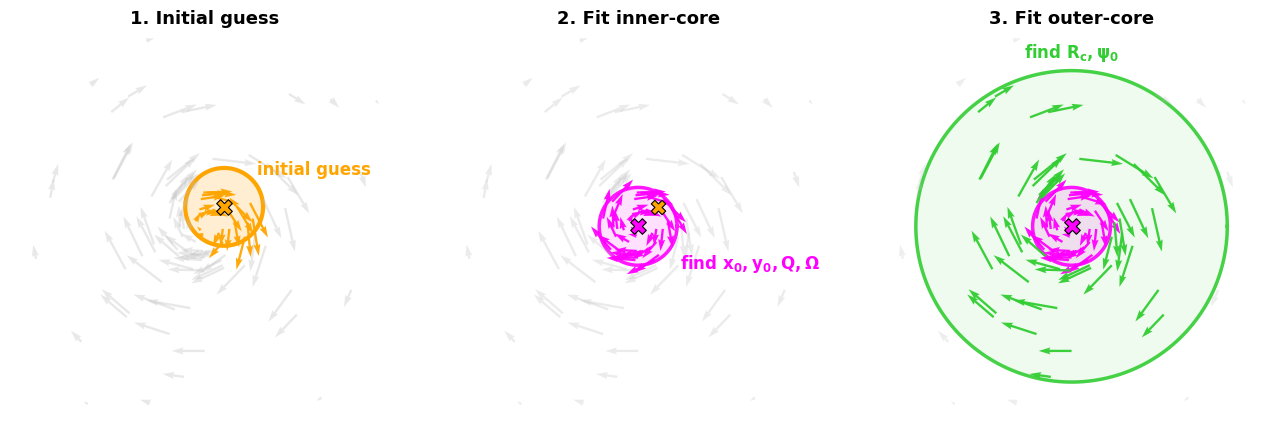

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(13, 4.2), sharex=True, sharey=True, constrained_layout=True)

n = 100
n_core = 40
n_outer = n - n_core

s = 90
spac = 1
scale = 22
width = 0.006

core_r = 30
outer_r = 120
outer_sample_r = 175

x0, y0 = 15, 15
lim = 150

init_color = 'orange'
core_color = 'magenta'
outer_color = 'limegreen'
faint_color = '0.75'

theta = np.linspace(0, 2*np.pi, 400)

# ---------------- Sample points ----------------
theta_core = 2*np.pi*np.random.rand(n_core)
r_core = core_r * np.sqrt(np.random.rand(n_core))

theta_outer = 2*np.pi*np.random.rand(n_outer)
r_outer = core_r + (outer_sample_r - core_r) * np.random.rand(n_outer)**2

xs = np.r_[r_core*np.cos(theta_core), r_outer*np.cos(theta_outer)]
ys = np.r_[r_core*np.sin(theta_core), r_outer*np.sin(theta_outer)]

idx = np.array([
    np.unravel_index(np.argmin((X - xx)**2 + (Y - yy)**2), X.shape)
    for xx, yy in zip(xs, ys)
])
ii, jj = idx[:, 0], idx[:, 1]

xi, yi = X[ii, jj], Y[ii, jj]
ui, vi = u[ii, jj], v[ii, jj]

# ---------------- Masks ----------------
init_mask = np.hypot(xi - x0, yi - y0) < core_r
core_mask = np.hypot(xi - xc, yi - yc) < core_r
bad_mask = init_mask & ~core_mask
other_mask_2 = ~(core_mask | bad_mask)

out_mask = np.hypot(xi - xc, yi - yc) < outer_r
out_mask = out_mask & ~core_mask
other_mask_3 = ~(core_mask | out_mask)

# ---------------- Common styling ----------------
for ax in axs:
    ax.set_aspect('equal')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# idealised eddy rings
# for ax in axs:
#     ax.add_patch(plt.Circle((xc, yc), outer_r, facecolor=outer_color, edgecolor='none', alpha=0.08, zorder=0))
#     ax.add_patch(plt.Circle((xc, yc), core_r,  facecolor=core_color,  edgecolor='none', alpha=0.12, zorder=0))
#     ax.plot(xc + core_r*np.cos(theta),  yc + core_r*np.sin(theta),  color=core_color,  lw=2.5, alpha=0.9, zorder=1)
#     ax.plot(xc + outer_r*np.cos(theta), yc + outer_r*np.sin(theta), color=outer_color, lw=2.5, alpha=0.9, zorder=1)

# ---------------- Panel 1 ----------------
axs[0].set_title('1. Initial guess', fontsize=13, weight='bold')

axs[0].add_patch(plt.Circle((x0, y0), core_r, facecolor=init_color, edgecolor='none', alpha=0.18, zorder=0))
axs[0].plot(x0 + core_r*np.cos(theta), y0 + core_r*np.sin(theta), color=init_color, lw=3, zorder=2)

axs[0].quiver(
    xi[~init_mask], yi[~init_mask], ui[~init_mask], vi[~init_mask],
    scale=scale, color=faint_color, alpha=0.35, width=width, zorder=2
)
axs[0].quiver(
    xi[init_mask], yi[init_mask], ui[init_mask], vi[init_mask],
    scale=scale, color=init_color, alpha=0.95, width=width, zorder=3
)

axs[0].scatter(x0, y0, marker='X', color=init_color, s=s*1.4, edgecolor='k', linewidths=0.8, zorder=5)
axs[0].text(x0 + 25, y0 + 25, 'initial guess', color=init_color, fontsize=12, weight='bold')

# ---------------- Panel 2 ----------------
axs[1].set_title('2. Fit inner-core', fontsize=13, weight='bold')

# axs[1].quiver(
#     xi[other_mask_2], yi[other_mask_2], ui[other_mask_2], vi[other_mask_2],
#     scale=scale, color=faint_color, alpha=0.30, width=width, zorder=2
# )
axs[1].quiver(
    xi[~core_mask], yi[~core_mask], ui[~core_mask], vi[~core_mask],
    scale=scale, color=faint_color, alpha=0.30, width=width, zorder=2
)
# axs[1].quiver(
#     xi[bad_mask], yi[bad_mask], ui[bad_mask], vi[bad_mask],
#     scale=scale, color=init_color, alpha=0.75, width=width, zorder=3
# )
axs[1].quiver(
    xi[core_mask], yi[core_mask], ui[core_mask], vi[core_mask],
    scale=scale, color=core_color, alpha=0.95, width=width, zorder=4
)

axs[1].add_patch(plt.Circle((xc, yc), core_r,  facecolor=core_color,  edgecolor='none', alpha=0.12, zorder=0))
axs[1].plot(xc + core_r*np.cos(theta),  yc + core_r*np.sin(theta),  color=core_color,  lw=2.5, alpha=0.9, zorder=1)

axs[1].scatter(x0, y0, marker='X', color=init_color, s=s*1.2, edgecolor='k', linewidths=0.8, zorder=5)
axs[1].scatter(xc, yc, marker='X', color=core_color, s=s*1.4, edgecolor='k', linewidths=0.8, zorder=6)

axs[1].text(xc + 32, yc - 32, r'find $\mathbf{x_0, y_0, Q, \Omega}$', color=core_color, fontsize=12, weight='bold')

# ---------------- Panel 3 ----------------
axs[2].set_title('3. Fit outer-core', fontsize=13, weight='bold')

axs[2].quiver(
    xi[other_mask_3], yi[other_mask_3], ui[other_mask_3], vi[other_mask_3],
    scale=scale, color=faint_color, alpha=0.25, width=width, zorder=2
)
axs[2].quiver(
    xi[core_mask], yi[core_mask], ui[core_mask], vi[core_mask],
    scale=scale, color=core_color, alpha=0.95, width=width, zorder=3
)
axs[2].quiver(
    xi[out_mask], yi[out_mask], ui[out_mask], vi[out_mask],
    scale=scale, color=outer_color, alpha=0.95, width=width, zorder=4
)

axs[2].scatter(xc, yc, marker='X', color=core_color, s=s*1.4, edgecolor='k', linewidths=0.8, zorder=5)

axs[2].add_patch(plt.Circle((xc, yc), core_r,  facecolor=core_color,  edgecolor='none', alpha=0.12, zorder=0))
axs[2].plot(xc + core_r*np.cos(theta),  yc + core_r*np.sin(theta),  color=core_color,  lw=2.5, alpha=0.9, zorder=1)

axs[2].add_patch(plt.Circle((xc, yc), outer_r, facecolor=outer_color, edgecolor='none', alpha=0.08, zorder=0))
axs[2].plot(xc + outer_r*np.cos(theta), yc + outer_r*np.sin(theta), color=outer_color, lw=2.5, alpha=0.9, zorder=1)


# # optional labels
# axs[2].text(xc, yc + core_r + 10, 'inner core', color=core_color, ha='center', fontsize=10, weight='bold')
axs[2].text(xc, yc + outer_r + 10, r'find $\mathbf{R_c, \psi_0}$', color=outer_color, ha='center', fontsize=12, weight='bold')
